In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv(r"D:\data analytics\storeitemdemand.csv")

# First look at the data
print(df.shape)
print(df.head())
print(df.info())

(913000, 4)
         date  store  item  sales
0  2013-01-01      1     1     13
1  2013-01-02      1     1     11
2  2013-01-03      1     1     14
3  2013-01-04      1     1     13
4  2013-01-05      1     1     10
<class 'pandas.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   date    913000 non-null  str  
 1   store   913000 non-null  int64
 2   item    913000 non-null  int64
 3   sales   913000 non-null  int64
dtypes: int64(3), str(1)
memory usage: 27.9 MB
None


In [4]:
# Fix date column
df['date'] = pd.to_datetime(df['date'])

# Check date range
print("Date range:", df['date'].min(), "to", df['date'].max())
print("Total stores:", df['store'].nunique())
print("Total items:", df['item'].nunique())
print(df.describe())

Date range: 2013-01-01 00:00:00 to 2017-12-31 00:00:00
Total stores: 10
Total items: 50
                      date          store           item          sales
count               913000  913000.000000  913000.000000  913000.000000
mean   2015-07-02 12:00:00       5.500000      25.500000      52.250287
min    2013-01-01 00:00:00       1.000000       1.000000       0.000000
25%    2014-04-02 00:00:00       3.000000      13.000000      30.000000
50%    2015-07-02 12:00:00       5.500000      25.500000      47.000000
75%    2016-10-01 00:00:00       8.000000      38.000000      70.000000
max    2017-12-31 00:00:00      10.000000      50.000000     231.000000
std                    NaN       2.872283      14.430878      28.801144


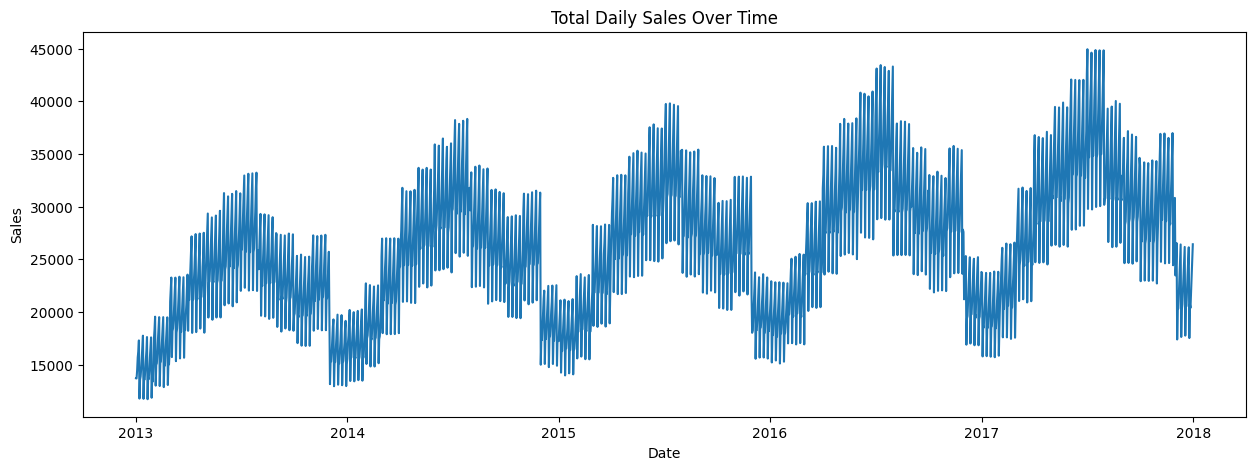

In [5]:
# Total sales over time
daily_sales = df.groupby('date')['sales'].sum().reset_index()

plt.figure(figsize=(15,5))
plt.plot(daily_sales['date'], daily_sales['sales'])
plt.title('Total Daily Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()

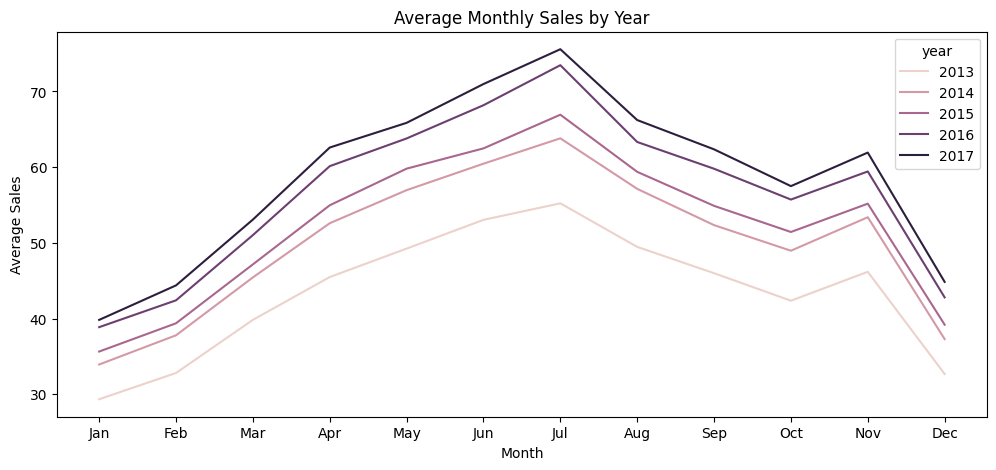

In [6]:
# Monthly sales pattern
df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year

monthly_sales = df.groupby(['year', 'month'])['sales'].mean().reset_index()

plt.figure(figsize=(12,5))
sns.lineplot(data=monthly_sales, x='month', y='sales', hue='year')
plt.title('Average Monthly Sales by Year')
plt.xlabel('Month')
plt.ylabel('Average Sales')
plt.xticks(range(1,13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.show()

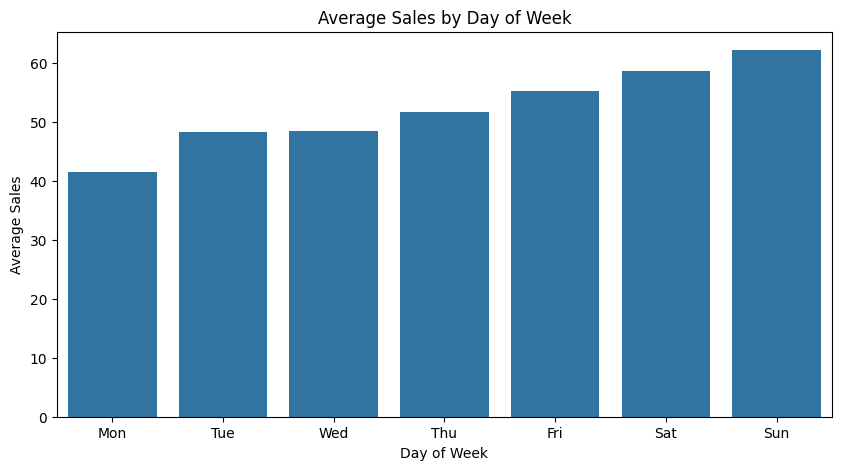

In [7]:
# Weekly pattern
df['dayofweek'] = df['date'].dt.dayofweek

weekly_sales = df.groupby('dayofweek')['sales'].mean().reset_index()

plt.figure(figsize=(10,5))
sns.barplot(data=weekly_sales, x='dayofweek', y='sales')
plt.title('Average Sales by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Sales')
plt.xticks(range(7), ['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
plt.show()

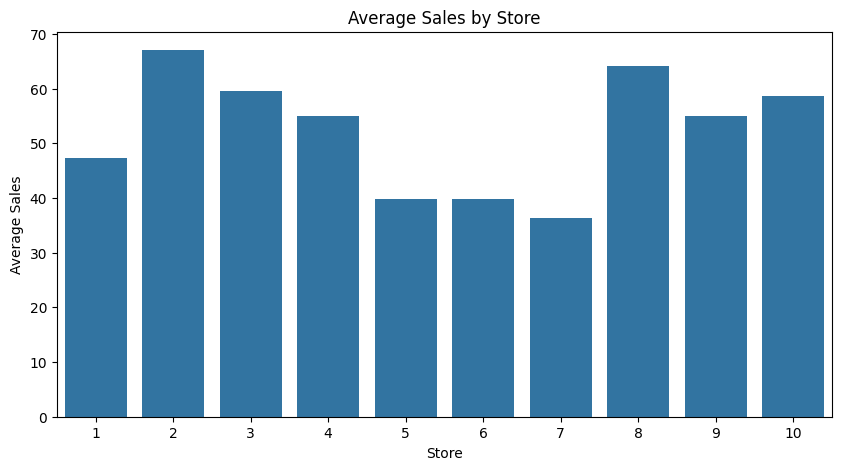

In [8]:
# Store wise sales
store_sales = df.groupby('store')['sales'].mean().reset_index()

plt.figure(figsize=(10,5))
sns.barplot(data=store_sales, x='store', y='sales')
plt.title('Average Sales by Store')
plt.xlabel('Store')
plt.ylabel('Average Sales')
plt.show()

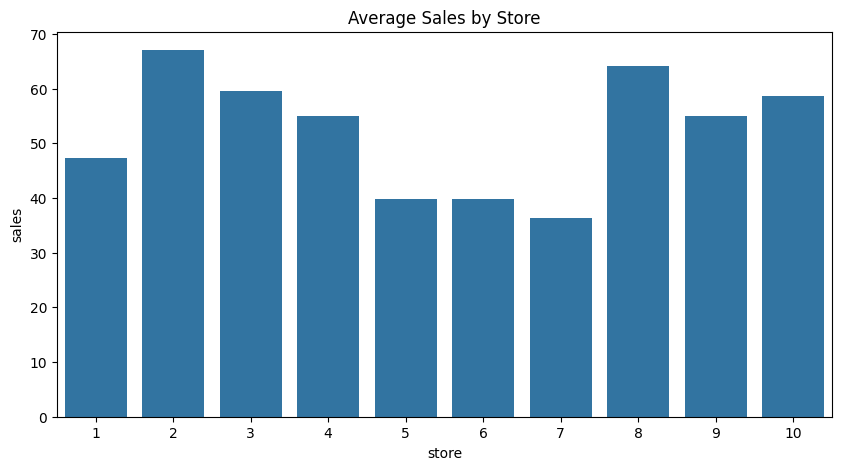

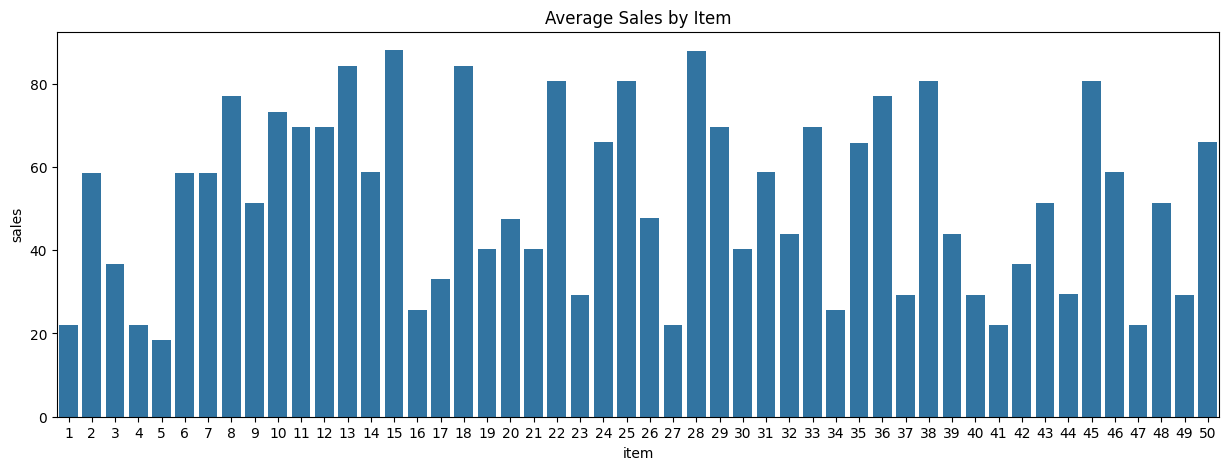

In [9]:
# Store wise sales
store_sales = df.groupby('store')['sales'].mean().reset_index()
plt.figure(figsize=(10,5))
sns.barplot(data=store_sales, x='store', y='sales')
plt.title('Average Sales by Store')
plt.show()

# Item wise sales
item_sales = df.groupby('item')['sales'].mean().reset_index()
plt.figure(figsize=(15,5))
sns.barplot(data=item_sales, x='item', y='sales')
plt.title('Average Sales by Item')
plt.show()

In [10]:
# Extract date features
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['dayofweek'] = df['date'].dt.dayofweek
df['quarter'] = df['date'].dt.quarter
df['weekofyear'] = df['date'].dt.isocalendar().week.astype(int)
df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)

# Lag features (previous sales)
df = df.sort_values(['store', 'item', 'date'])
df['lag_7'] = df.groupby(['store', 'item'])['sales'].shift(7)    # sales 7 days ago
df['lag_30'] = df.groupby(['store', 'item'])['sales'].shift(30)   # sales 30 days ago
df['lag_365'] = df.groupby(['store', 'item'])['sales'].shift(365) # sales 1 year ago

# Rolling mean features
df['rolling_mean_7'] = df.groupby(['store', 'item'])['sales'].transform(lambda x: x.shift(1).rolling(7).mean())
df['rolling_mean_30'] = df.groupby(['store', 'item'])['sales'].transform(lambda x: x.shift(1).rolling(30).mean())

# Drop nulls created by lag features
df.dropna(inplace=True)

print(df.shape)
print(df.head())

(730500, 16)
          date  store  item  sales  month  year  dayofweek  day  quarter  \
365 2014-01-01      1     1      9      1  2014          2    1        1   
366 2014-01-02      1     1     14      1  2014          3    2        1   
367 2014-01-03      1     1     11      1  2014          4    3        1   
368 2014-01-04      1     1     20      1  2014          5    4        1   
369 2014-01-05      1     1     17      1  2014          6    5        1   

     weekofyear  is_weekend  lag_7  lag_30  lag_365  rolling_mean_7  \
365           1           0    6.0     8.0     13.0       13.000000   
366           1           0   16.0    21.0     11.0       13.428571   
367           1           0   18.0     6.0     14.0       13.142857   
368           1           1   17.0    13.0     13.0       12.142857   
369           1           1   14.0    15.0     10.0       12.571429   

     rolling_mean_30  
365        12.400000  
366        12.433333  
367        12.200000  
368        

In [11]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Define features and target
features = ['store', 'item', 'year', 'month', 'day', 'dayofweek', 
            'quarter', 'weekofyear', 'is_weekend',
            'lag_7', 'lag_30', 'lag_365', 
            'rolling_mean_7', 'rolling_mean_30']

X = df[features]
y = df['sales']

# Split data — use last year as test
train = df[df['year'] < 2017]
test = df[df['year'] == 2017]

X_train = train[features]
y_train = train['sales']
X_test = test[features]
y_test = test['sales']

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (548000, 14)
Test size: (182500, 14)


In [12]:
from sklearn.ensemble import RandomForestRegressor

# Train the model
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")

RMSE: 8.19
MAE: 6.30


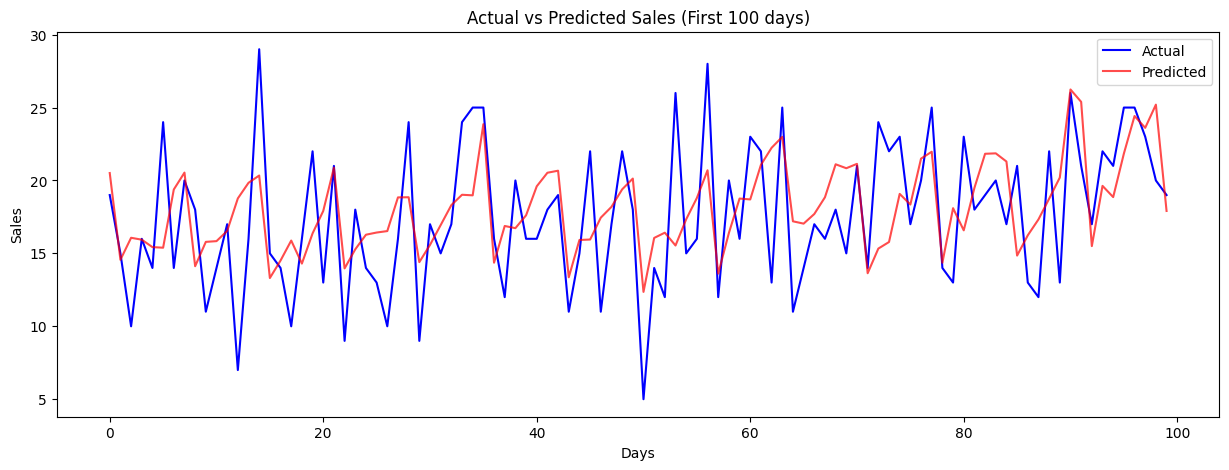

In [13]:
# Plot actual vs predicted
plt.figure(figsize=(15,5))
plt.plot(y_test.values[:100], label='Actual', color='blue')
plt.plot(y_pred[:100], label='Predicted', color='red', alpha=0.7)
plt.title('Actual vs Predicted Sales (First 100 days)')
plt.xlabel('Days')
plt.ylabel('Sales')
plt.legend()
plt.show()

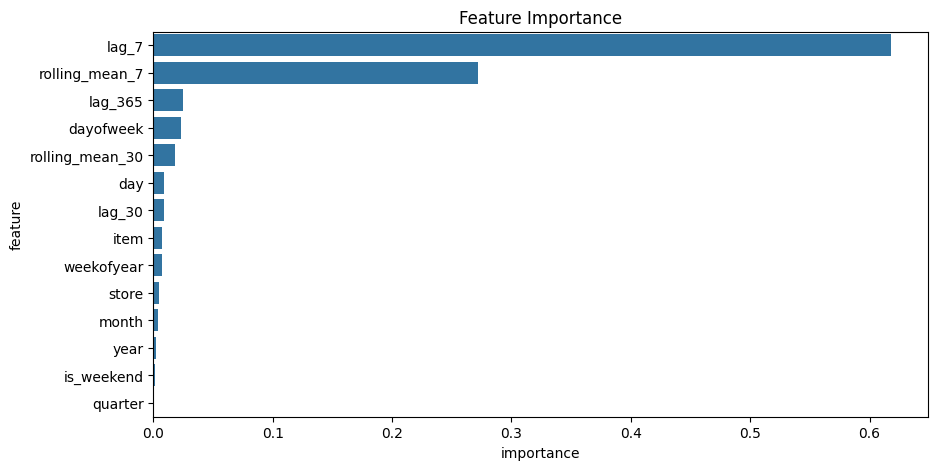

In [14]:
# Feature importance
feat_imp = pd.DataFrame({
    'feature': features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(data=feat_imp, x='importance', y='feature')
plt.title('Feature Importance')
plt.show()

In [15]:
import joblib
joblib.dump(model, 'demand_forecast_model.pkl')
print("Model saved!")

OSError: [Errno 28] No space left on device